# 🎬 Movies Dataset — Exploratory Data Analysis

### 1. Import Libraries

In [34]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### 2. Load the Dataset

In [35]:
df = pd.read_csv('../movies.csv')
df.head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


### 3. Data Inspection

In [36]:
# Shape
print("Shape:", df.shape)

# Column names
print("\nColumns:", df.columns.tolist())

Shape: (9742, 3)

Columns: ['movieId', 'title', 'genres']


In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9742 entries, 0 to 9741
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   movieId  9742 non-null   int64 
 1   title    9742 non-null   object
 2   genres   9742 non-null   object
dtypes: int64(1), object(2)
memory usage: 228.5+ KB


In [38]:
# Missing values
df.isnull().sum()

movieId    0
title      0
genres     0
dtype: int64

### 4. Data Cleaning

The `title` column contains both the movie name and release year (e.g., `"Toy Story (1995)"`).  
We will separate these into two new columns: **Title** and **Year**.

In [39]:
# Extract year from title into its own column
df['year'] = df['title'].str.extract(r'\((\d{4})\)').astype('Int64')

# Remove the year (and surrounding parentheses) from the title
df['title'] = df['title'].str.replace(r'\s*\(\d{4}\)', '', regex=True).str.strip()

df.head()

,movieId,title,genres,year
0,1,Toy Story,Adventure|Animation|Children|Comedy|Fantasy,1995
1,2,Jumanji,Adventure|Children|Fantasy,1995
2,3,Grumpier Old Men,Comedy|Romance,1995
3,4,Waiting to Exhale,Comedy|Drama|Romance,1995
4,5,Father of the Bride Part II,Comedy,1995


In [40]:
# Save the cleaned dataset
df.to_csv('movies_clean.csv', index=False)
print("Saved movies_clean.csv")

Saved movies_clean.csv


### 5. Data Analysis & Visualizations

In [41]:
# Split genres into a list (each movie may belong to multiple genres)
df['genres'] = df['genres'].str.split('|')
df.head()

,movieId,title,genres,year
0,1,Toy Story,"[Adventure, Animation, Children, Comedy, Fantasy]",1995
1,2,Jumanji,"[Adventure, Children, Fantasy]",1995
2,3,Grumpier Old Men,"[Comedy, Romance]",1995
3,4,Waiting to Exhale,"[Comedy, Drama, Romance]",1995
4,5,Father of the Bride Part II,[Comedy],1995


      movieId                         title     genres  year
0           1                     Toy Story  Adventure  1995
0           1                     Toy Story  Animation  1995
0           1                     Toy Story   Children  1995
0           1                     Toy Story     Comedy  1995
0           1                     Toy Story    Fantasy  1995
...       ...                           ...        ...   ...
9738   193583         No Game No Life: Zero    Fantasy  2017
9739   193585                         Flint      Drama  2017
9740   193587  Bungo Stray Dogs: Dead Apple     Action  2018
9740   193587  Bungo Stray Dogs: Dead Apple  Animation  2018
9741   193609  Andrew Dice Clay: Dice Rules     Comedy  1991

[22084 rows x 4 columns]
genres
Drama                 4361
Comedy                3756
Thriller              1894
Action                1828
Romance               1596
Adventure             1263
Crime                 1199
Sci-Fi                 980
Horror             

/var/folders/2t/d63krzxd18v_gv5_zv2typ880000gn/T/ipykernel_71942/3668733816.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=genre_counts.values, y=genre_counts.index, palette='viridis')


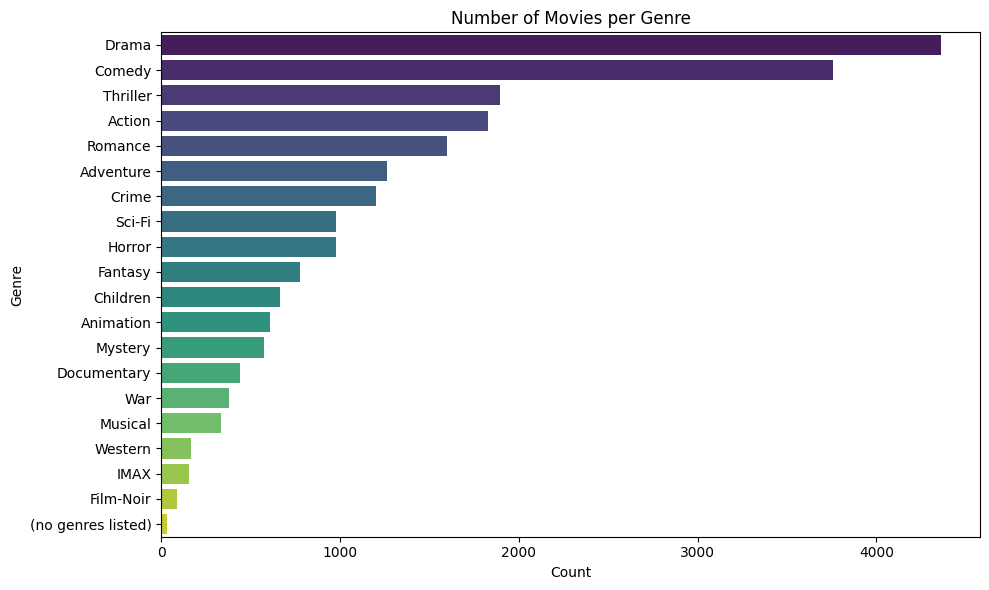

In [45]:
# Explode genres so each row represents one movie-genre pair
df_exploded = df.explode('genres')
print(df_exploded)

# --- Chart 1: Genre Distribution ---
genre_counts = df_exploded['genres'].value_counts()
print(genre_counts)

plt.figure(figsize=(10, 6))
sns.barplot(x=genre_counts.values, y=genre_counts.index, palette='viridis')
plt.title('Number of Movies per Genre')
plt.xlabel('Count')
plt.ylabel('Genre')
plt.tight_layout()
plt.show()

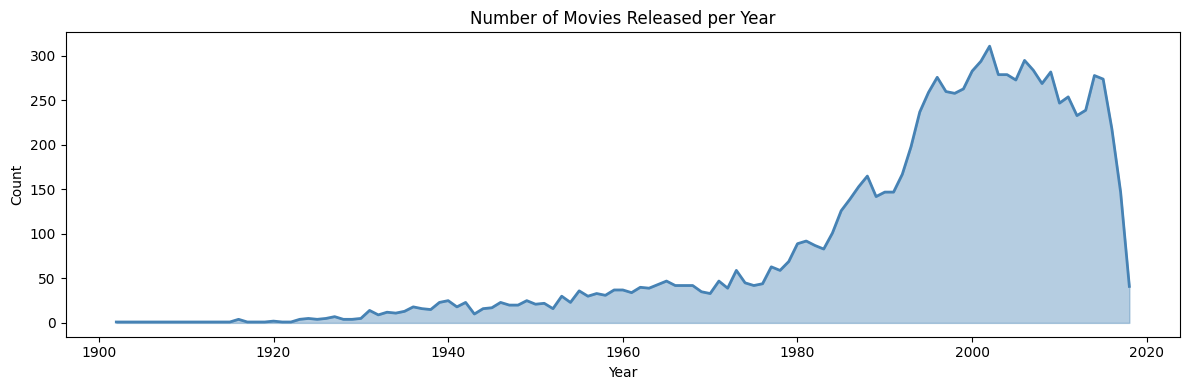

In [46]:
# --- Chart 2: Movies released per year ---
movies_per_year = df.groupby('year')['title'].count()

plt.figure(figsize=(12, 4))
plt.fill_between(movies_per_year.index, movies_per_year.values, alpha=0.4, color='steelblue')
plt.plot(movies_per_year.index, movies_per_year.values, color='steelblue', linewidth=2)
plt.title('Number of Movies Released per Year')
plt.xlabel('Year')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

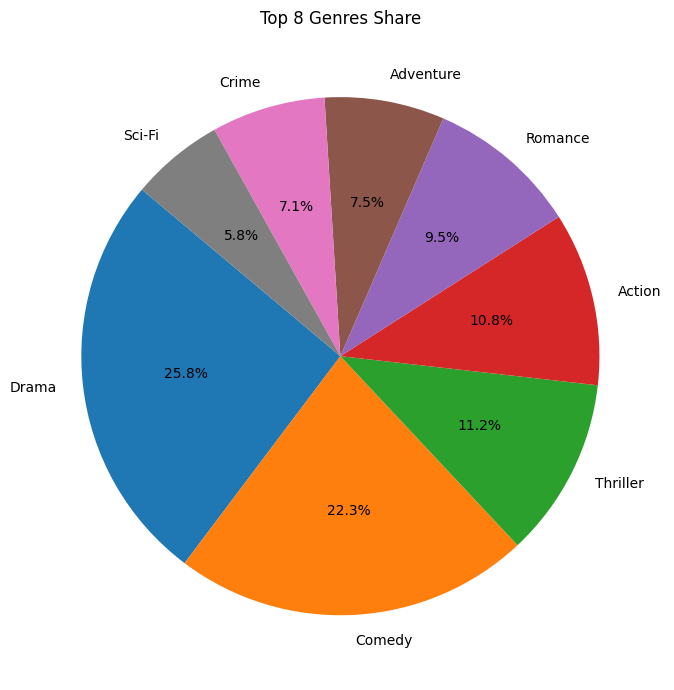

In [ ]:
# --- Chart 3: Top 5 genres share (pie chart) ---
top_genres = df_exploded['genres'].value_counts().head(5)

plt.figure(figsize=(7, 7))
plt.pie(top_genres.values, labels=top_genres.index, autopct='%1.1f%%', startangle=140)
plt.title('Top 5 Genres Share')
plt.tight_layout()
plt.show()

### 6. Key Findings

- **Drama** and **Comedy** are by far the most common genres in the dataset.
- The majority of movies were released in the **1990s**, reflecting the time period the dataset covers.
- A small number of genres (Drama, Comedy, Thriller, Action, Romance) account for the majority of all genre tags.
- Many movies belong to **multiple genres** simultaneously — the exploded count is therefore higher than the total movie count.